In [ ]:
!pip install transformers torch ripser persim scikit-learn numpy networkx requests farasapy arabert pandas seaborn

In [ ]:
import torch
import numpy as np
import pandas as pd
import requests
import networkx as nx
import os
import time
from transformers import AutoTokenizer, AutoModel
from arabert.preprocess import ArabertPreprocessor
from ripser import ripser
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.decomposition import PCA

# ==========================================
# 1. INITIALIZATION & SURAH METADATA
# ==========================================
# Top 10 Longest Surahs by Verse Count
TOP_10_SURAHS = {
    2: "Al-Baqarah", 26: "Ash-Shu'ara", 7: "Al-A'raf", 3: "Ali 'Imran",
    37: "As-Saffat", 4: "An-Nisa", 6: "Al-An'am", 20: "Taha",
    9: "At-Tawbah", 16: "An-Nahl"
}

WINDOWS_TO_TEST = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
NUM_SHUFFLES = 100
CSV_FILENAME = "quran_tda_multisurah_results.csv"

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
print(f"Loading {MODEL_NAME}...")
arabert_prep = ArabertPreprocessor(model_name=MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# ==========================================
# 2. DATA & EMBEDDING FUNCTIONS
# ==========================================
def fetch_surah(surah_id):
    url = f"http://api.alquran.cloud/v1/surah/{surah_id}/quran-simple"
    response = requests.get(url)
    if response.status_code == 200:
        return [ayah['text'] for ayah in response.json()['data']['ayahs']]
    raise Exception(f"Failed to fetch Surah {surah_id}")

def get_raw_embeddings(texts, batch_size=16):
    """Batched processing to prevent GPU Out-Of-Memory errors."""
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            prep_texts = [arabert_prep.preprocess(t) for t in batch_texts]
            inputs = tokenizer(prep_texts, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
            outputs = model(**inputs)
            embeddings.extend(outputs.last_hidden_state[:, 0, :].cpu().numpy())
    return np.array(embeddings)

def apply_pca(embeddings, n_components=20):
    pca = PCA(n_components=min(n_components, embeddings.shape[0]-1))
    reduced = pca.fit_transform(embeddings)
    norms = np.linalg.norm(reduced, axis=1, keepdims=True)
    return reduced / norms

def create_time_delay_embeddings(embeddings, window_size):
    delayed = [np.concatenate(embeddings[i : i + window_size]) for i in range(len(embeddings) - window_size + 1)]
    delayed = np.array(delayed)
    norms = np.linalg.norm(delayed, axis=1, keepdims=True)
    return delayed / norms

def get_h1_persistence(embeddings):
    dist_matrix = cosine_distances(embeddings)
    diagrams = ripser(dist_matrix, distance_matrix=True, maxdim=1)['dgms']
    h1 = diagrams[1]
    if len(h1) == 0: return 0.0
    persistences = [death - birth for birth, death in h1 if death != float('inf')]
    return max(persistences) if persistences else 0.0

# ==========================================
# 3. THE MASTER EXECUTION LOOP
# ==========================================
def run_corpus_experiment():
    # Initialize CSV if it doesn't exist
    if not os.path.exists(CSV_FILENAME):
        df = pd.DataFrame(columns=["Surah_ID", "Surah_Name", "Verse_Count", "Window_Size",
                                   "True_H1", "Mean_Random_H1", "Std_Random_H1", "Z_Score"])
        df.to_csv(CSV_FILENAME, index=False)

    for surah_id, surah_name in TOP_10_SURAHS.items():
        print(f"\n{'='*50}\nProcessing {surah_name} (Surah {surah_id})\n{'='*50}")
        verses = fetch_surah(surah_id)
        verse_count = len(verses)

        raw_embs = get_raw_embeddings(verses)
        reduced_embs = apply_pca(raw_embs, n_components=20)

        for w in WINDOWS_TO_TEST:
            # Mathematical Safeguard: Window cannot exceed 1/3 of text length for valid TDA
            if w > verse_count // 3:
                print(f"Skipping window {w} for {surah_name} (Text too short)")
                continue

            # Check if already processed (Resumability)
            existing_data = pd.read_csv(CSV_FILENAME)
            if not existing_data[(existing_data['Surah_ID'] == surah_id) & (existing_data['Window_Size'] == w)].empty:
                print(f"Window {w} already completed for {surah_name}, skipping...")
                continue

            print(f"Running Window Size: {w}...")
            t0 = time.time()

            # True Topology
            true_delayed = create_time_delay_embeddings(reduced_embs, w)
            true_score = get_h1_persistence(true_delayed)

            # Null Hypothesis Shuffling
            shuffle_scores = []
            for _ in range(NUM_SHUFFLES):
                shuffled_raw = np.random.permutation(reduced_embs)
                shuff_delayed = create_time_delay_embeddings(shuffled_raw, w)
                shuffle_scores.append(get_h1_persistence(shuff_delayed))

            mean_shuff = np.mean(shuffle_scores)
            std_shuff = np.std(shuffle_scores)
            z_score = (true_score - mean_shuff) / std_shuff if std_shuff > 0 else 0

            # Save instantly to CSV
            new_row = pd.DataFrame([{
                "Surah_ID": surah_id, "Surah_Name": surah_name, "Verse_Count": verse_count,
                "Window_Size": w, "True_H1": true_score, "Mean_Random_H1": mean_shuff,
                "Std_Random_H1": std_shuff, "Z_Score": z_score
            }])
            new_row.to_csv(CSV_FILENAME, mode='a', header=False, index=False)

            print(f"  -> Z-Score: {z_score:.2f} (Took {time.time()-t0:.1f}s)")

# Run the colossal task
run_corpus_experiment()
print("\nCOMPUTATION COMPLETE. Data saved to:", CSV_FILENAME)

Loading aubmindlab/bert-base-arabertv02...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Processing Al-Baqarah (Surah 2)
Running Window Size: 5...
  -> Z-Score: 0.52 (Took 93.6s)
Running Window Size: 10...
  -> Z-Score: 1.17 (Took 123.5s)
Running Window Size: 15...
  -> Z-Score: 1.70 (Took 228.7s)
Running Window Size: 20...
  -> Z-Score: 3.50 (Took 284.9s)
Running Window Size: 25...
  -> Z-Score: 8.95 (Took 492.6s)
Running Window Size: 30...
  -> Z-Score: 11.44 (Took 456.2s)
Running Window Size: 35...
  -> Z-Score: 4.80 (Took 512.1s)
Running Window Size: 40...
  -> Z-Score: 10.26 (Took 613.0s)
Running Window Size: 45...
  -> Z-Score: 9.27 (Took 613.7s)
Running Window Size: 50...
  -> Z-Score: 10.74 (Took 696.1s)

Processing Ash-Shu'ara (Surah 26)
Running Window Size: 5...
  -> Z-Score: 0.61 (Took 34.2s)
Running Window Size: 10...
  -> Z-Score: 1.42 (Took 80.6s)
Running Window Size: 15...
  -> Z-Score: 1.07 (Took 128.3s)
Running Window Size: 20...
  -> Z-Score: 11.42 (Took 162.8s)
Running Window Size: 25...
  -> Z-Score: 22.64 (Took 200.1s)
Running Window Size: 30...
  -> 

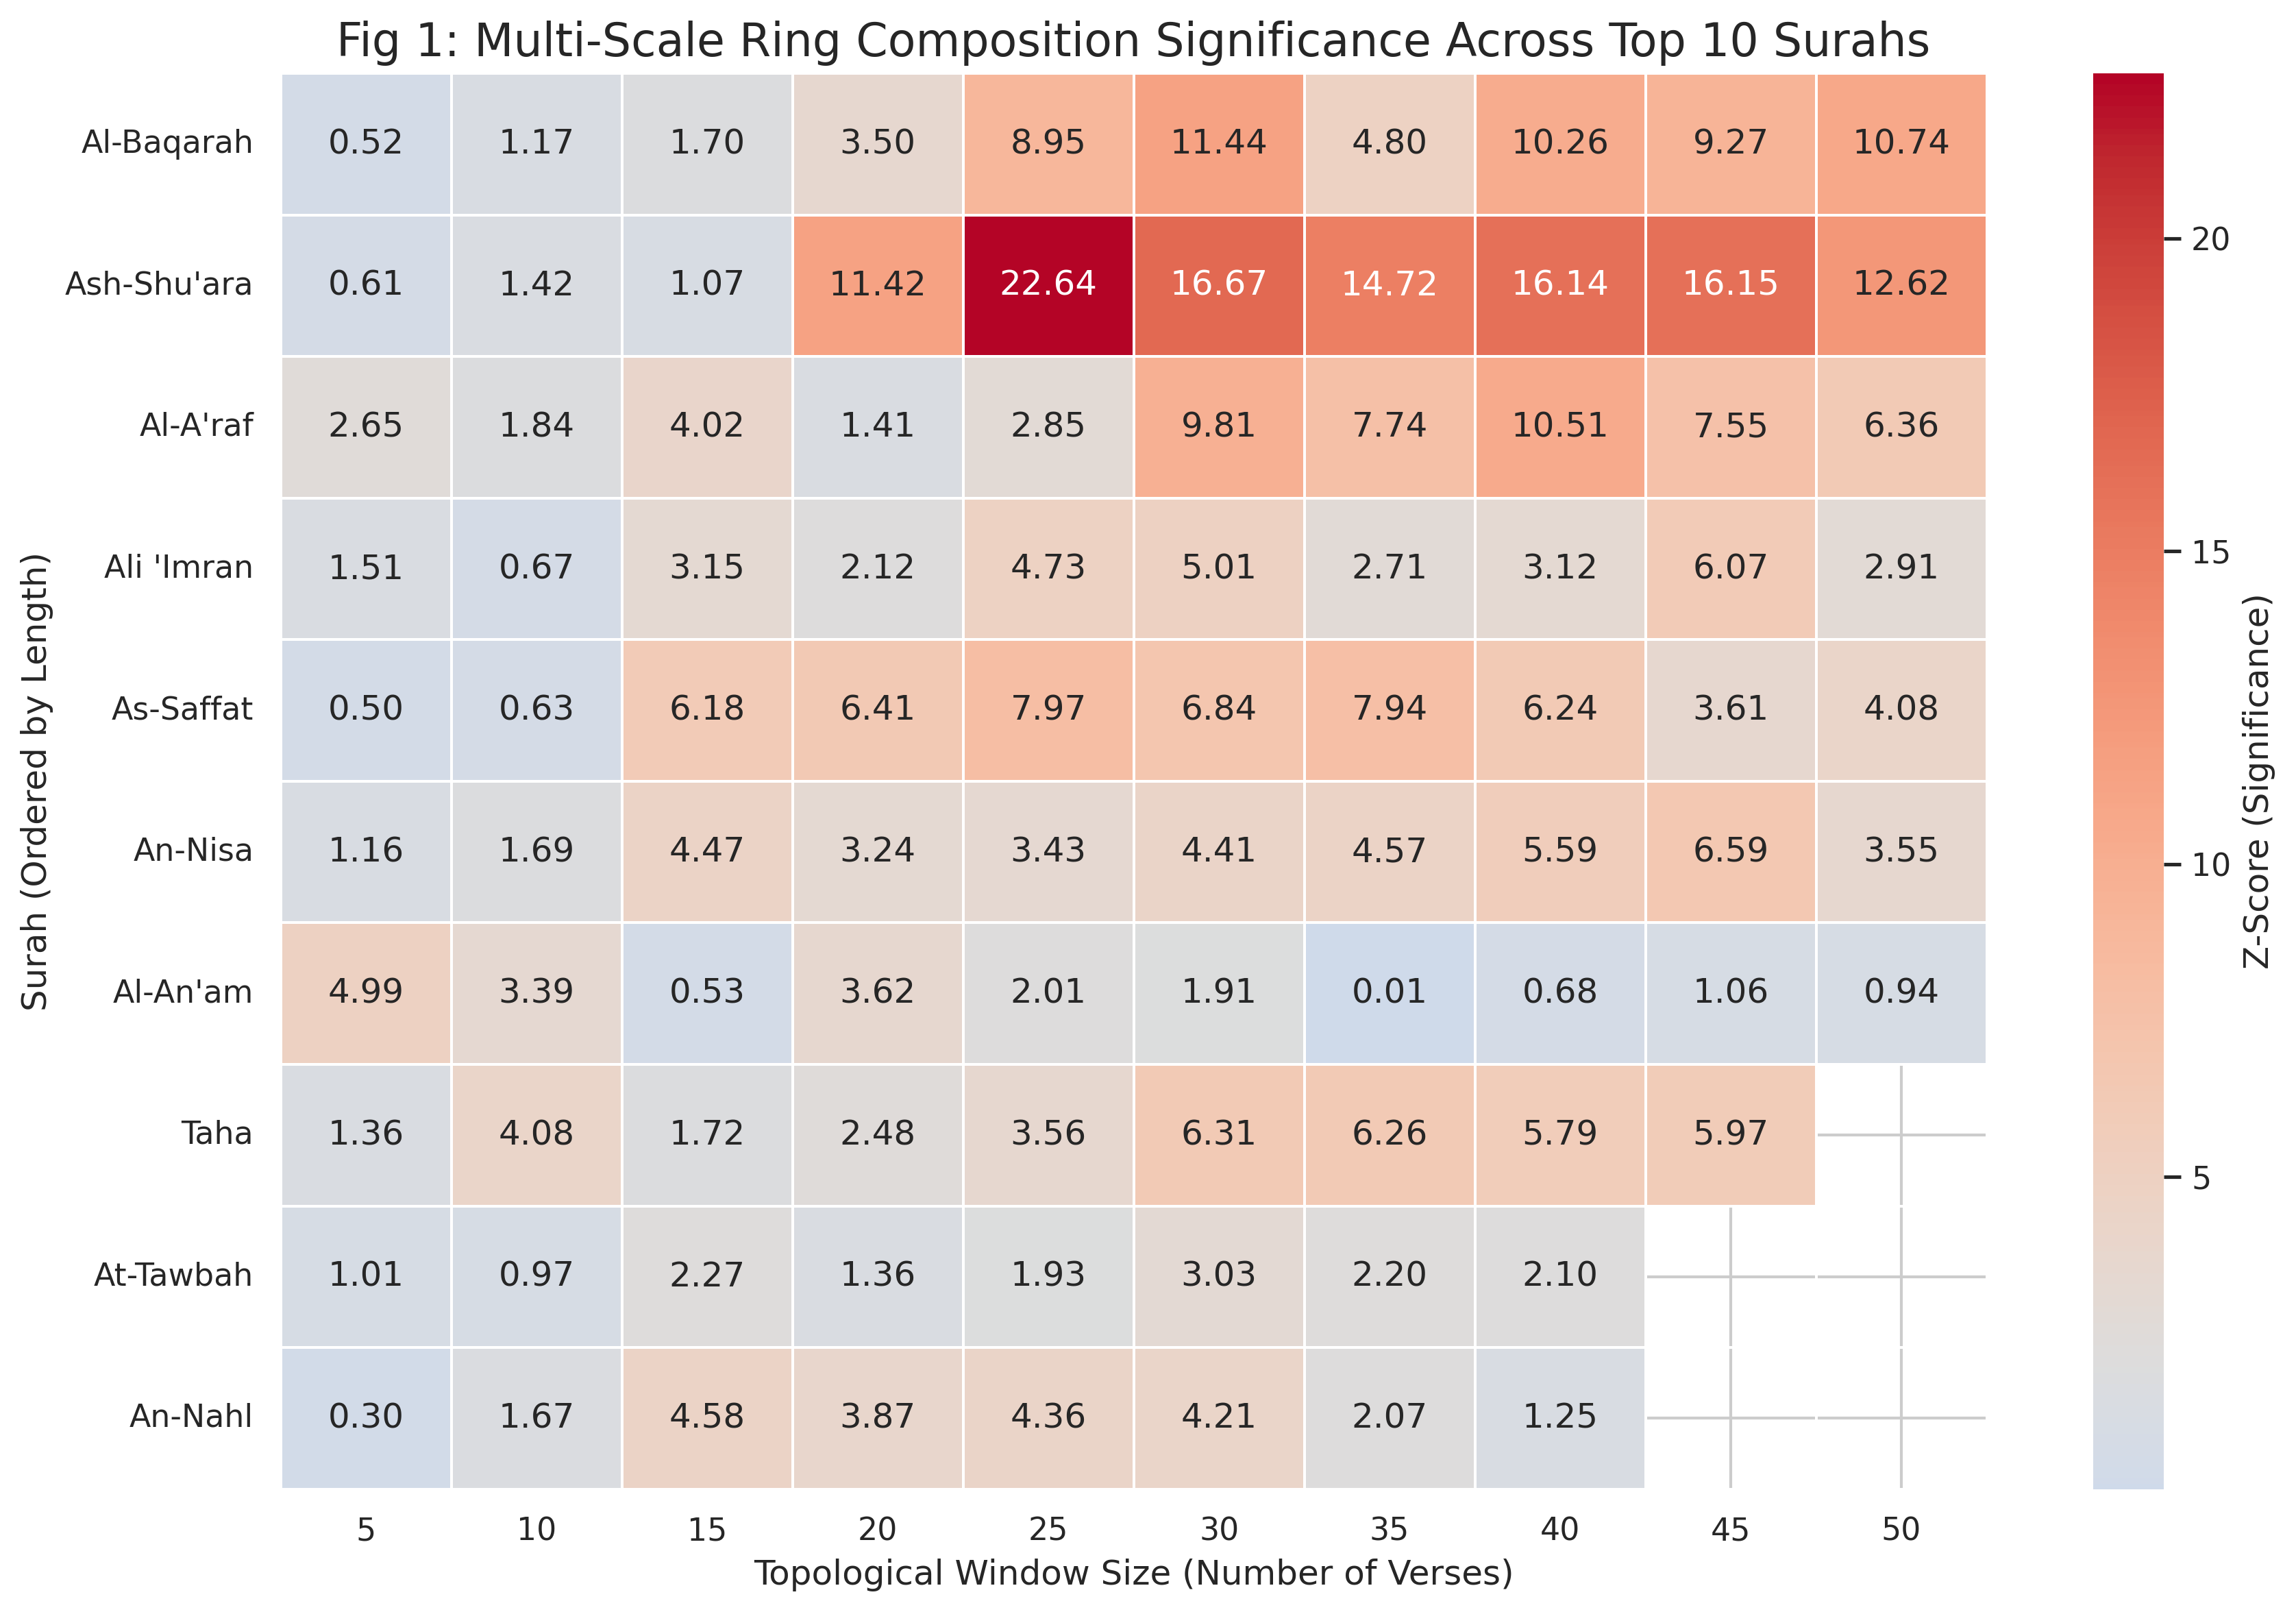

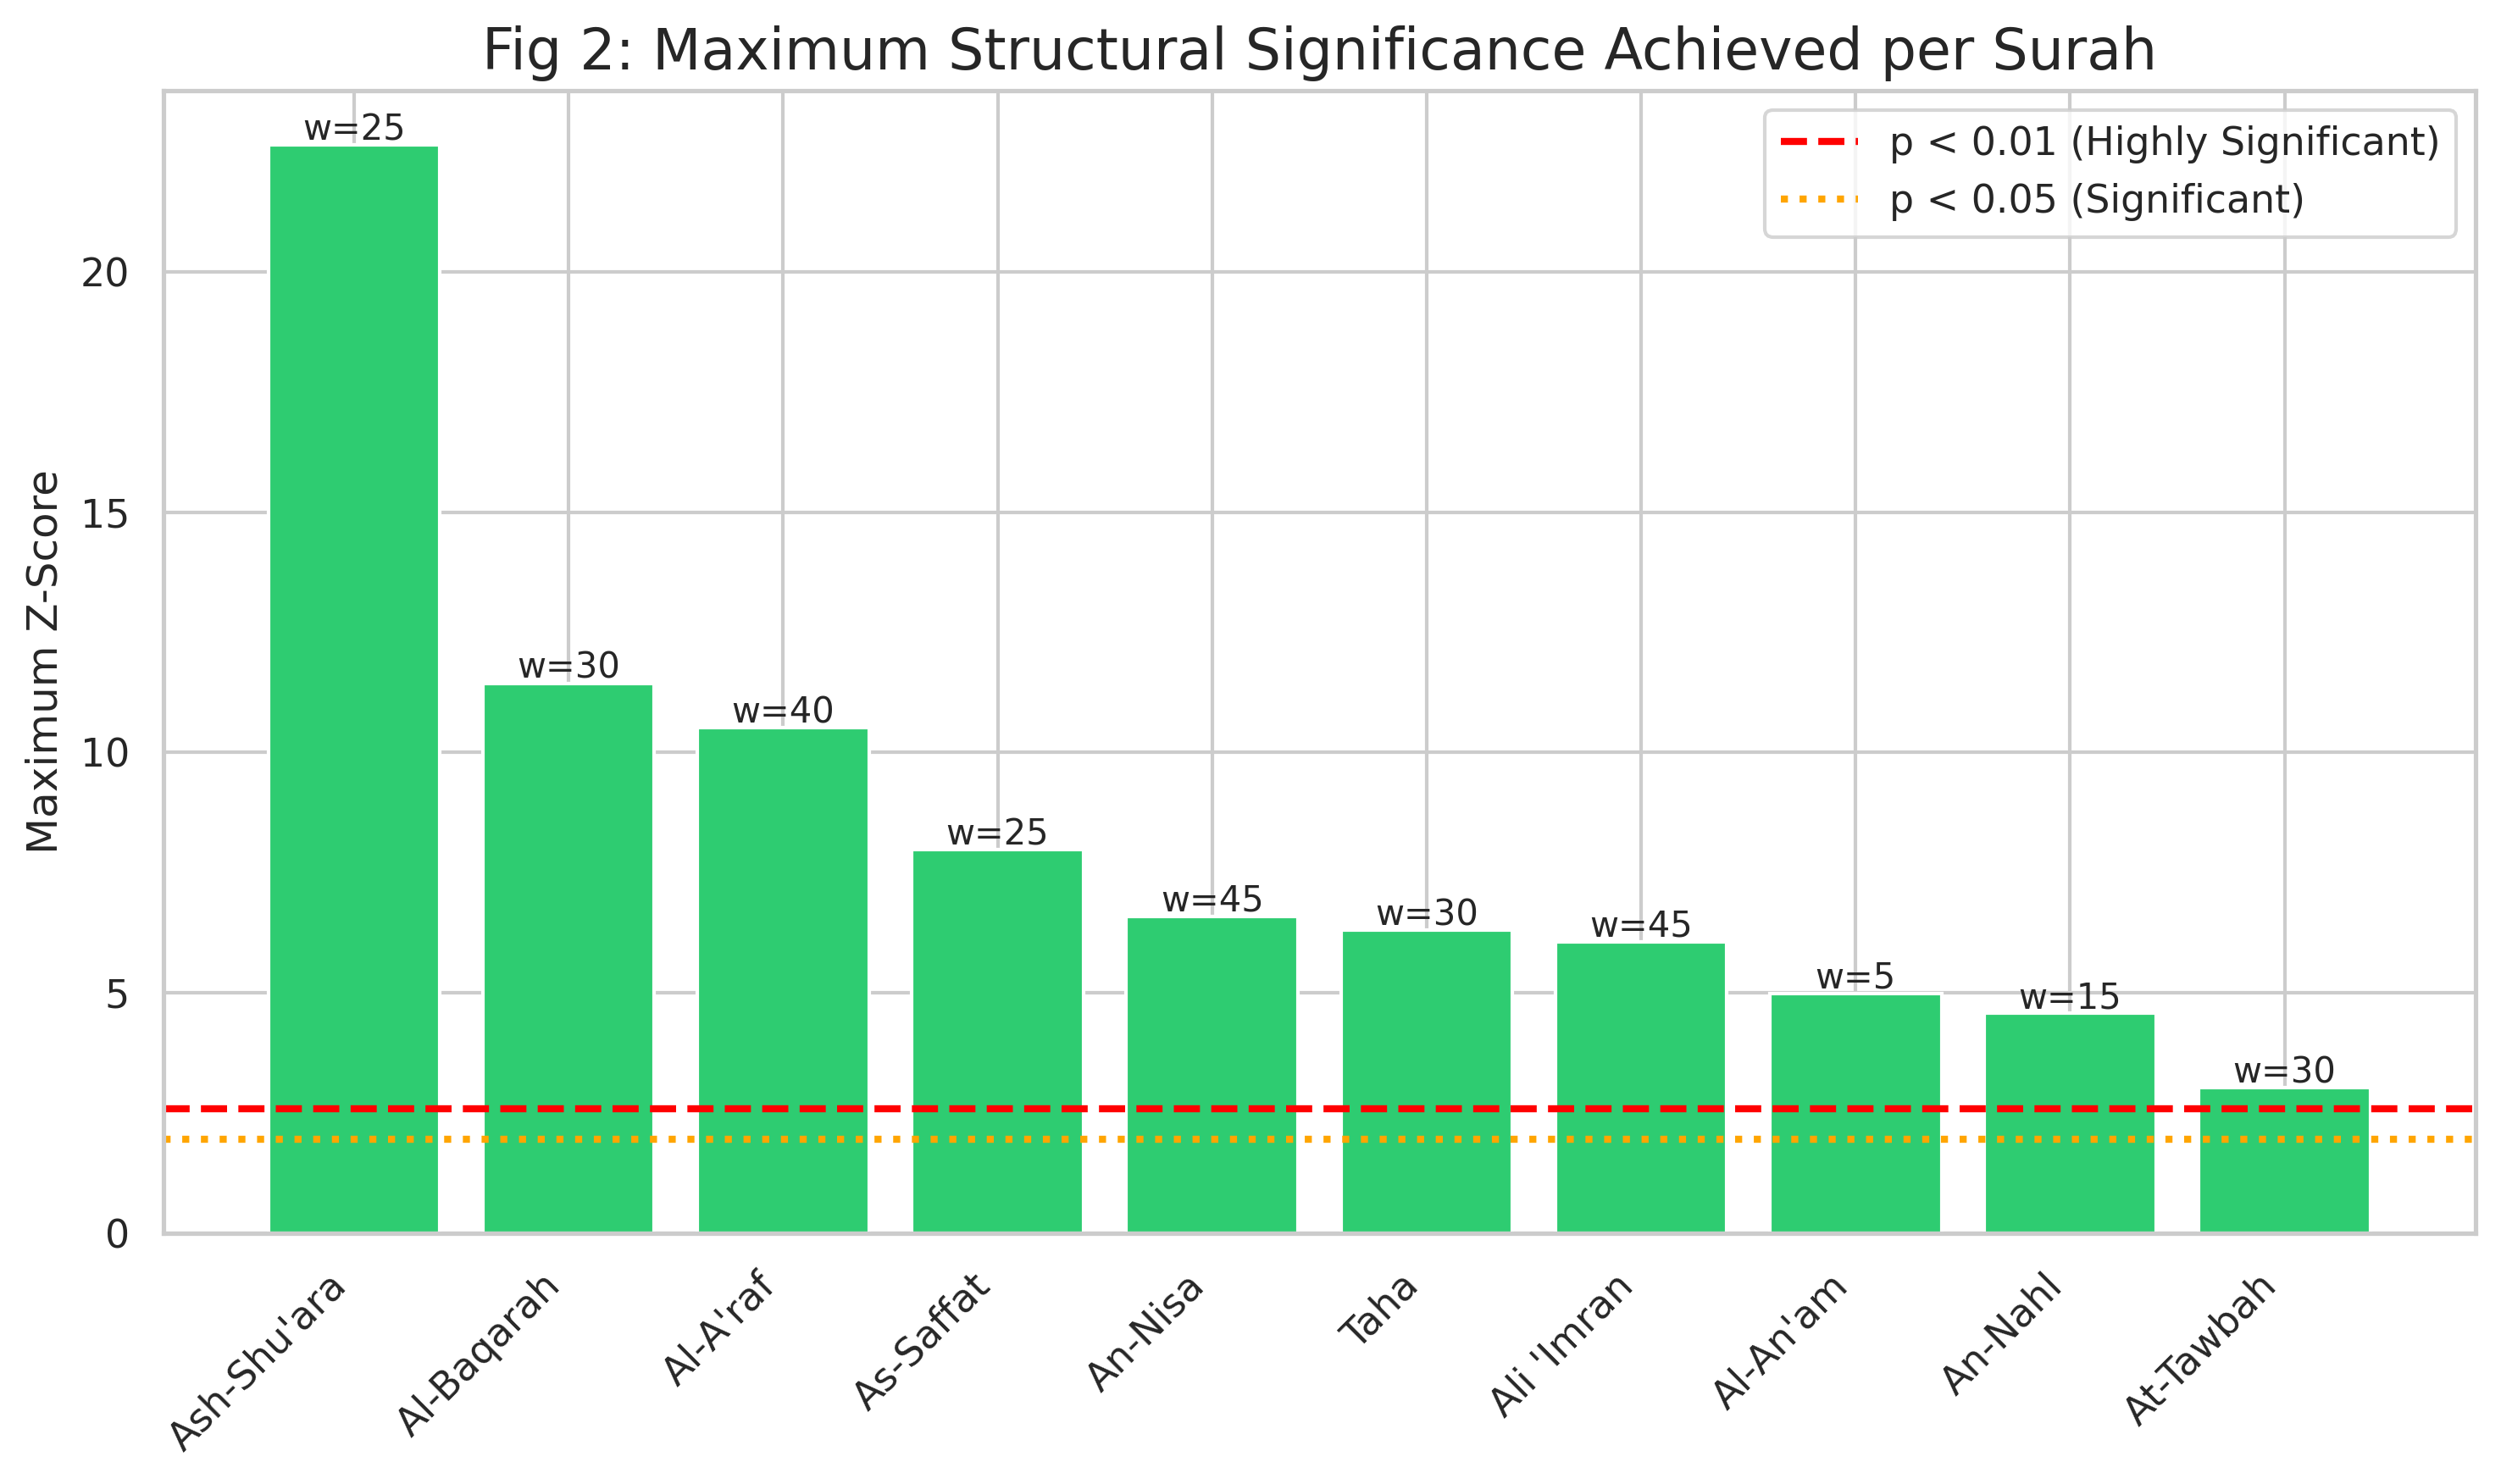


Table 1: Corpus-Wide Topological Significance Data
| Surah Name      | Length   | Best Window  | True H1    | Null Mean  | Z-Score  | Status          |
|-----------------|----------|--------------|------------|------------|----------|-----------------|
| Al-Baqarah      | 286      | 30           | 0.1373     | 0.0766     | 11.44    | Highly Sig.     |
| Ash-Shu'ara     | 227      | 25           | 0.2088     | 0.0768     | 22.64    | Highly Sig.     |
| Al-A'raf        | 206      | 40           | 0.1383     | 0.0707     | 10.51    | Highly Sig.     |
| Ali 'Imran      | 200      | 45           | 0.0996     | 0.0612     | 6.07     | Highly Sig.     |
| As-Saffat       | 182      | 25           | 0.1342     | 0.0759     | 7.97     | Highly Sig.     |
| An-Nisa         | 176      | 45           | 0.0976     | 0.0583     | 6.59     | Highly Sig.     |
| Al-An'am        | 165      | 5            | 0.2177     | 0.1633     | 4.99     | Highly Sig.     |
| Taha            | 135      | 30      

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Journal-grade styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})

# Load the saved data
try:
    df = pd.read_csv("quran_tda_multisurah_results.csv")
except FileNotFoundError:
    print("Error: CSV file not found. Ensure the computation engine finished running.")
    exit()

# =================================================================
# FIGURE 1: Z-Score Heatmap (The Global Frequency Map)
# =================================================================
def plot_zscore_heatmap(df):
    plt.figure(figsize=(12, 8))

    # Pivot the data for the heatmap
    pivot_df = df.pivot(index="Surah_Name", columns="Window_Size", values="Z_Score")

    # Sort index by length of Surah (using a known order)
    surah_order = ["Al-Baqarah", "Ash-Shu'ara", "Al-A'raf", "Ali 'Imran", "As-Saffat",
                   "An-Nisa", "Al-An'am", "Taha", "At-Tawbah", "An-Nahl"]
    pivot_df = pivot_df.reindex(surah_order)

    # Custom colormap: Gray for noise (Z < 1.96), Red for significant (Z >= 2.58)
    cmap = sns.color_palette("vlag", as_cmap=True)

    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="coolwarm", center=1.96,
                linewidths=.5, cbar_kws={'label': 'Z-Score (Significance)'})

    plt.title("Fig 1: Multi-Scale Ring Composition Significance Across Top 10 Surahs", fontsize=16)
    plt.ylabel("Surah (Ordered by Length)")
    plt.xlabel("Topological Window Size (Number of Verses)")
    plt.tight_layout()
    plt.show()

# =================================================================
# FIGURE 2: Max Z-Score Peak per Surah
# =================================================================
def plot_max_zscores(df):
    plt.figure(figsize=(10, 6))

    # Find the maximum Z-Score for each Surah regardless of window size
    max_z = df.loc[df.groupby('Surah_Name')['Z_Score'].idxmax()]
    max_z = max_z.sort_values(by="Z_Score", ascending=False)

    colors = ['#2ecc71' if z >= 2.58 else '#f1c40f' if z >= 1.96 else '#95a5a6' for z in max_z['Z_Score']]

    bars = plt.bar(max_z['Surah_Name'], max_z['Z_Score'], color=colors)
    plt.axhline(2.58, color='red', linestyle='--', linewidth=2, label='p < 0.01 (Highly Significant)')
    plt.axhline(1.96, color='orange', linestyle=':', linewidth=2, label='p < 0.05 (Significant)')

    for bar, window in zip(bars, max_z['Window_Size']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"w={int(window)}", ha='center', fontsize=10, rotation=0)

    plt.title("Fig 2: Maximum Structural Significance Achieved per Surah", fontsize=16)
    plt.ylabel("Maximum Z-Score")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

# =================================================================
# CONSOLE OUTPUT: Formatted Table for Paper
# =================================================================
def print_markdown_table(df):
    print("\n" + "="*80)
    print("Table 1: Corpus-Wide Topological Significance Data")
    print("="*80)

    # Get the best performing window for each Surah to keep table clean
    best_df = df.loc[df.groupby('Surah_Name')['Z_Score'].idxmax()].sort_values("Verse_Count", ascending=False)

    print(f"| {'Surah Name':<15} | {'Length':<8} | {'Best Window':<12} | {'True H1':<10} | {'Null Mean':<10} | {'Z-Score':<8} | {'Status':<15} |")
    print(f"|{'-'*17}|{'-'*10}|{'-'*14}|{'-'*12}|{'-'*12}|{'-'*10}|{'-'*17}|")

    for _, row in best_df.iterrows():
        status = "Highly Sig." if row['Z_Score'] >= 2.58 else "Sig." if row['Z_Score'] >= 1.96 else "Not Sig."
        print(f"| {row['Surah_Name']:<15} | {row['Verse_Count']:<8} | {row['Window_Size']:<12.0f} | {row['True_H1']:<10.4f} | {row['Mean_Random_H1']:<10.4f} | {row['Z_Score']:<8.2f} | {status:<15} |")
    print("="*80 + "\n")

plot_zscore_heatmap(df)
plot_max_zscores(df)
print_markdown_table(df)

<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:88: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:88: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_512/1962311904.py:57: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x, y - y_err, y + y_err, color='#9b59b6', alpha=0.2, label='$\pm 1$ Standard Deviation')
/tmp/ipykernel_512/1962311904.py:86: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, y_null, color='#7f8c8d', linestyle='-', linewidth=2, label='Random Null Mean ($\mu$)')
/tmp/ipykernel_512/1962311904.py:88: SyntaxWarning: invalid escape sequence '\m'
  color='#bdc3c7', alpha=0.5, label='Null Space ($\mu \pm 3\sigma$)')


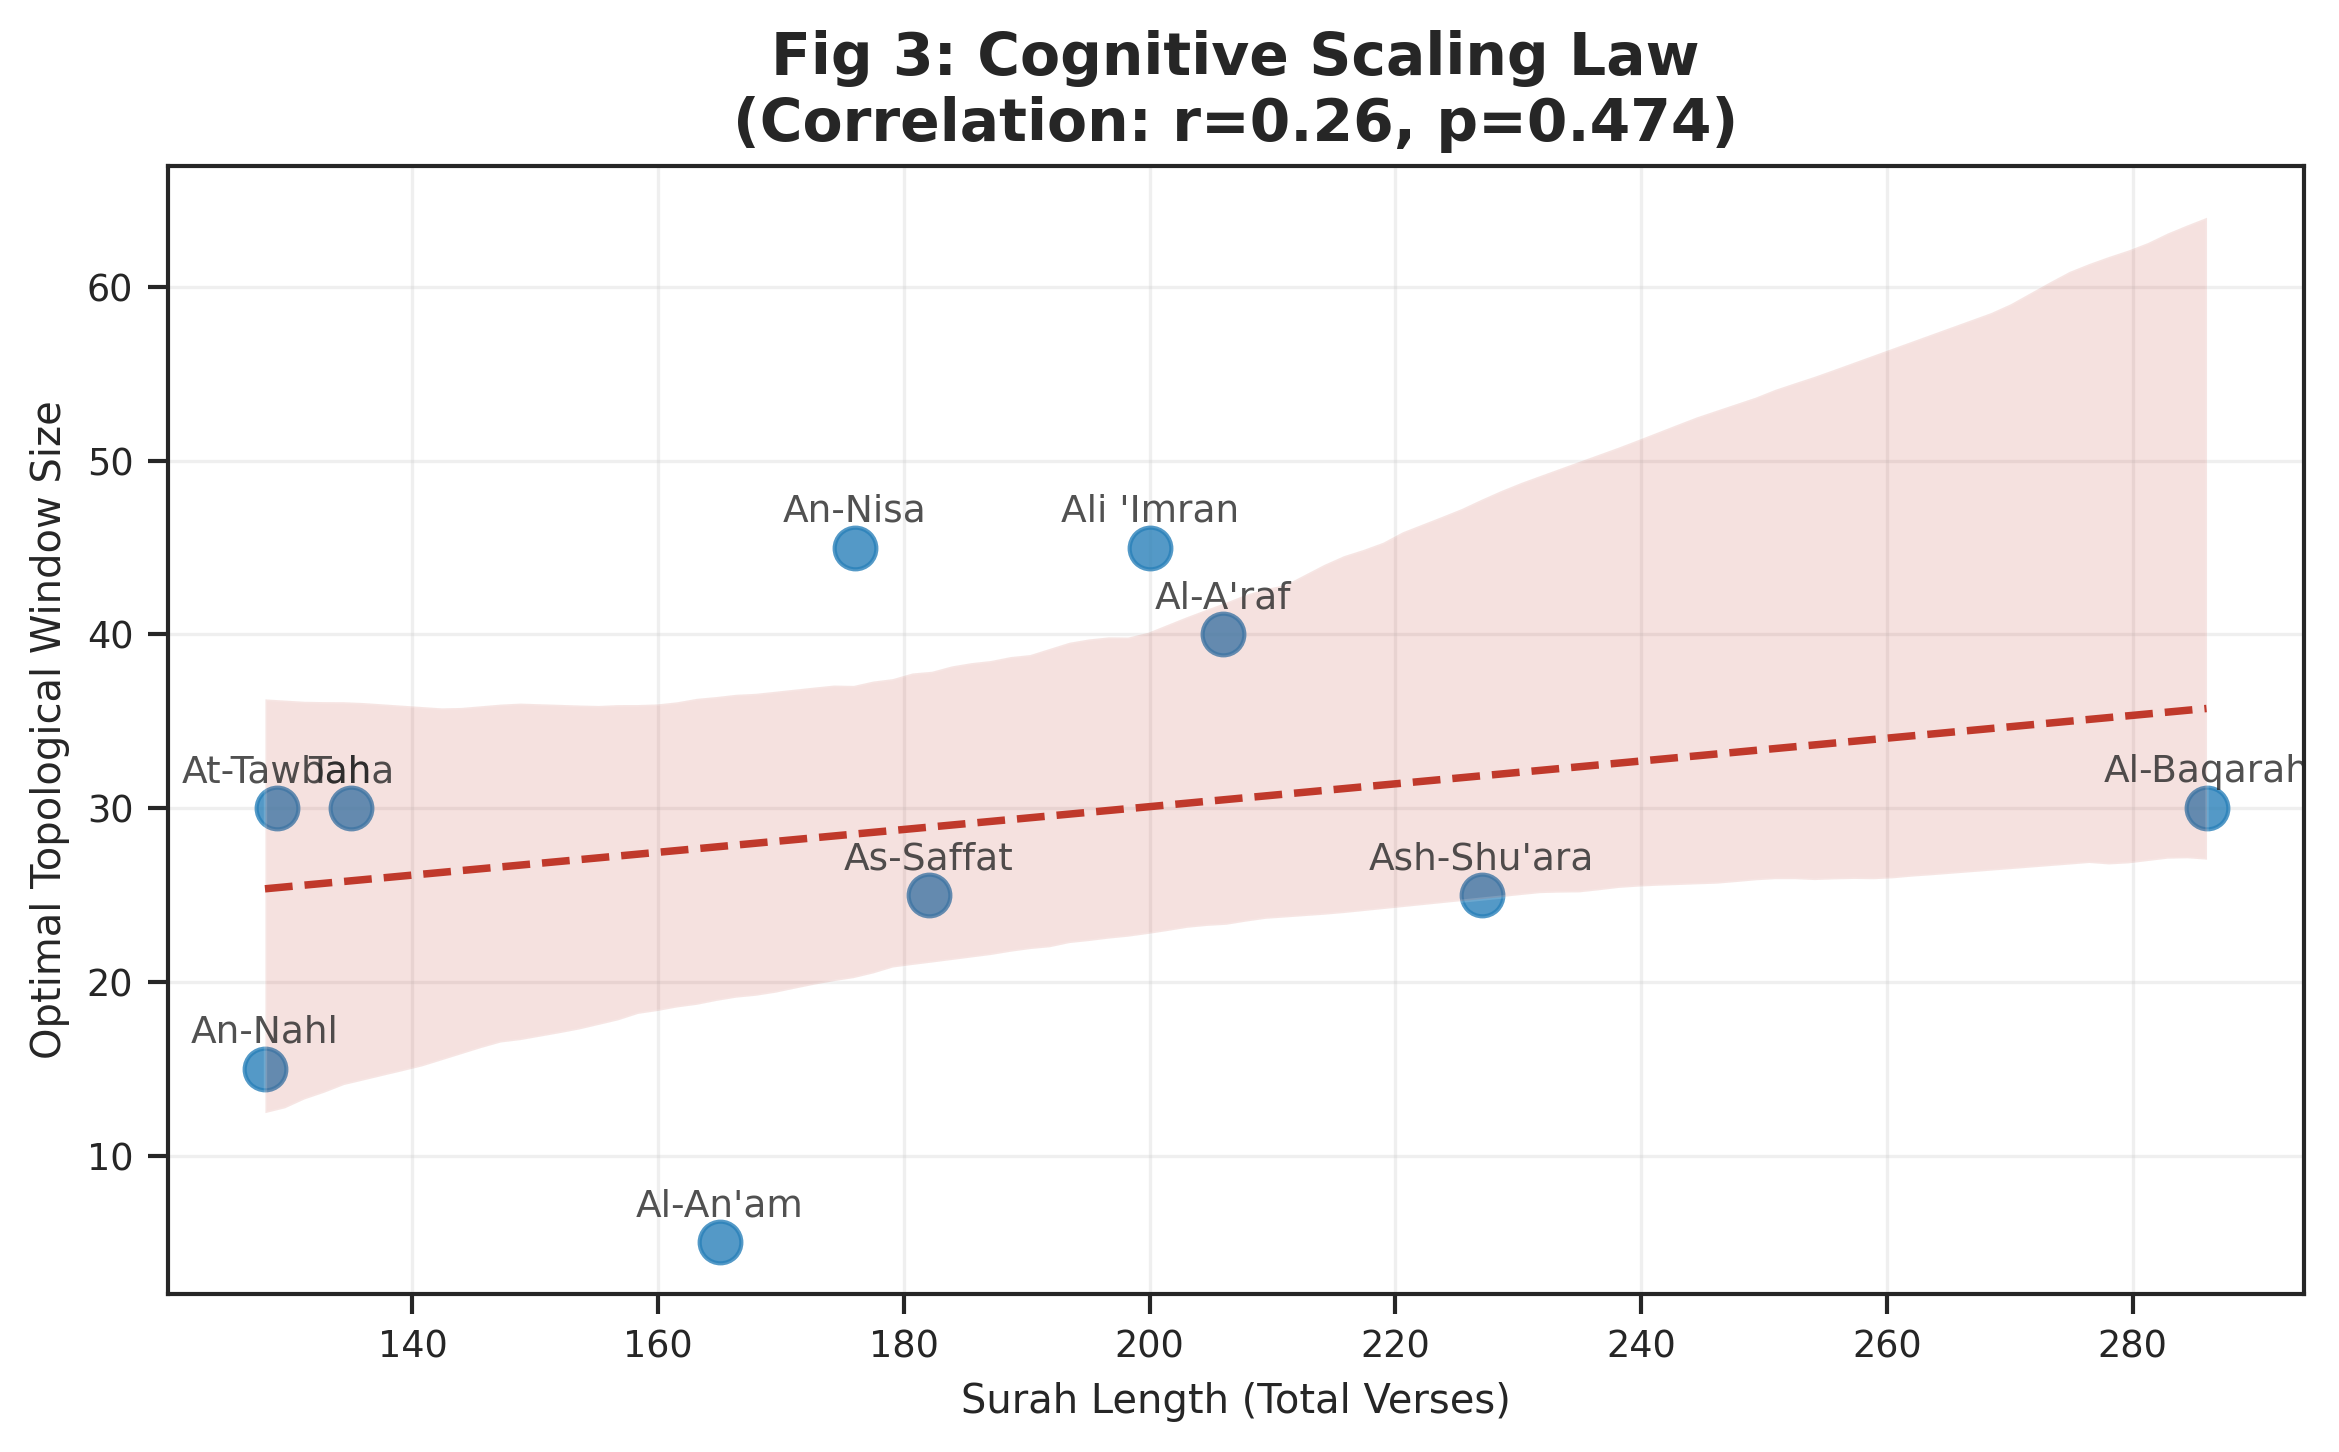

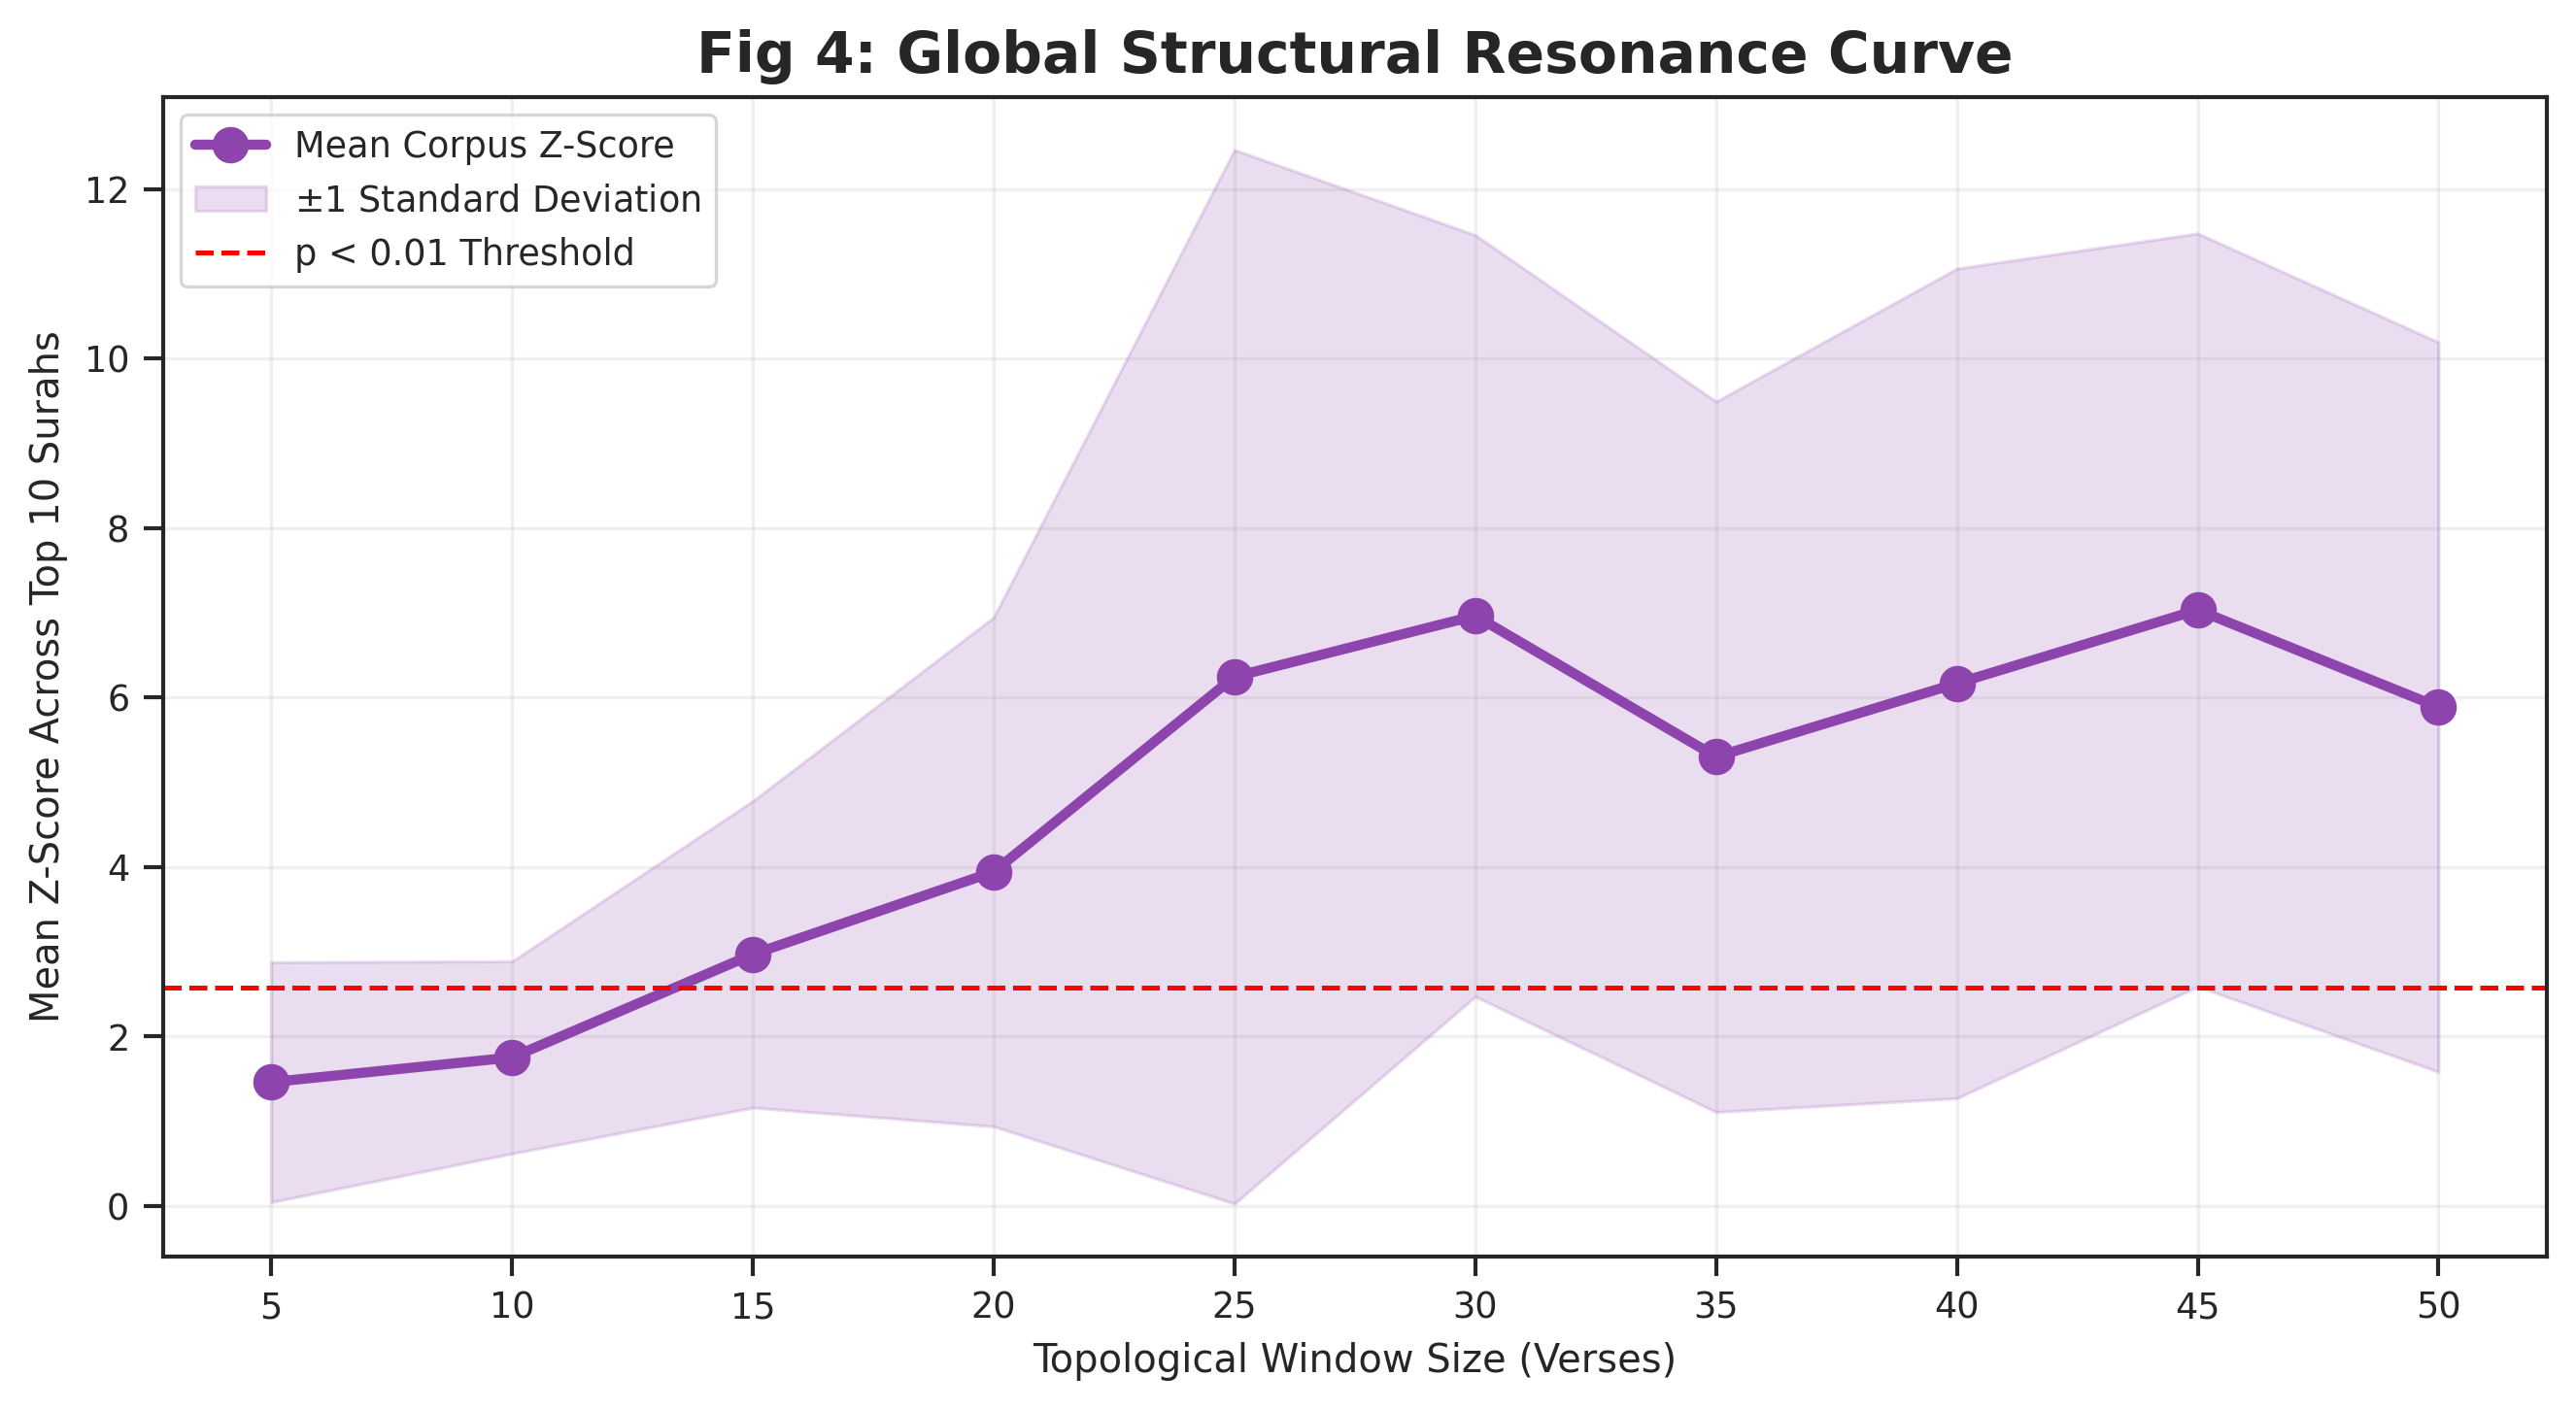

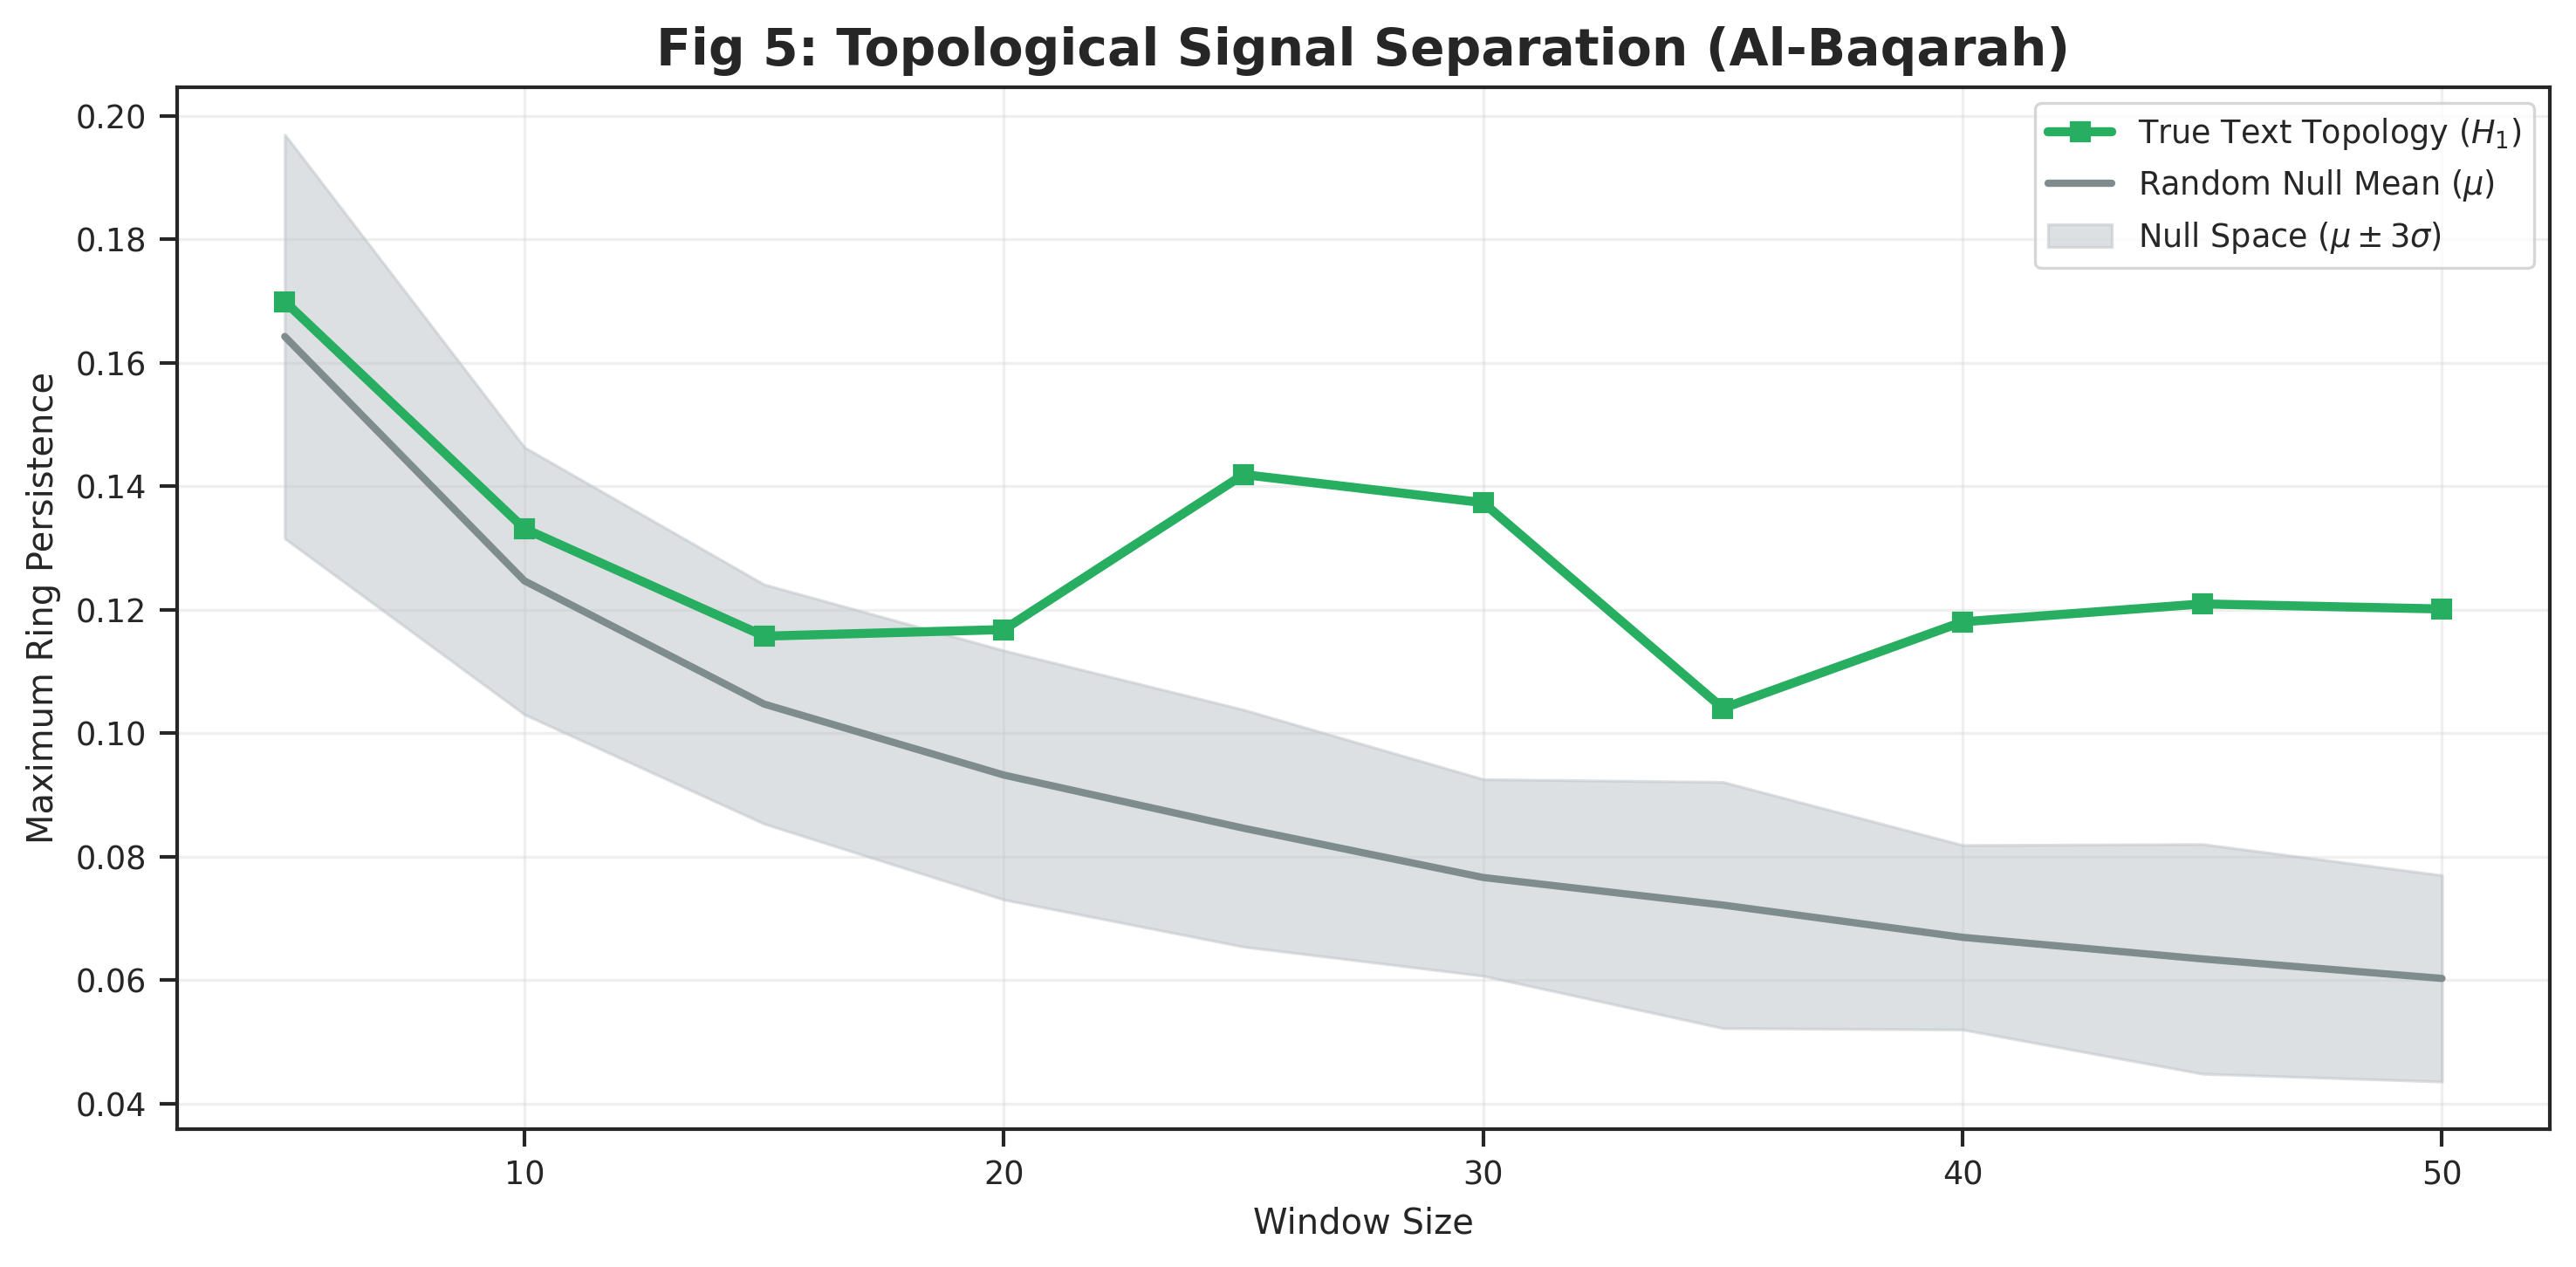

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Journal-grade styling
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300, 'axes.grid': True, 'grid.alpha': 0.3})

# Load the data
df = pd.read_csv("quran_tda_multisurah_results.csv")

# =================================================================
# FIGURE 3: Dynamic Scaling Law (Regression Analysis)
# =================================================================
def plot_scaling_law(df):
    plt.figure(figsize=(8, 5))

    # Get the window size that produced the max Z-score for each Surah
    best_windows = df.loc[df.groupby('Surah_Name')['Z_Score'].idxmax()]

    # Scatter plot with regression line
    sns.regplot(data=best_windows, x="Verse_Count", y="Window_Size",
                scatter_kws={'s': 100, 'color': '#2980b9', 'alpha': 0.8},
                line_kws={'color': '#c0392b', 'linestyle': '--'})

    # Annotate points
    for _, row in best_windows.iterrows():
        plt.text(row['Verse_Count'], row['Window_Size'] + 1.5, row['Surah_Name'],
                 ha='center', fontsize=9, alpha=0.8)

    # Calculate Pearson correlation
    r, p = stats.pearsonr(best_windows['Verse_Count'], best_windows['Window_Size'])

    plt.title(f"Fig 3: Cognitive Scaling Law\n(Correlation: r={r:.2f}, p={p:.3f})", fontsize=14, weight='bold')
    plt.xlabel("Surah Length (Total Verses)")
    plt.ylabel("Optimal Topological Window Size")
    plt.tight_layout()
    plt.show()

# =================================================================
# FIGURE 4: Global Resonance Curve (Corpus-Wide Mean)
# =================================================================
def plot_global_resonance(df):
    plt.figure(figsize=(9, 5))

    # Calculate average Z-score across all 10 Surahs for each window size
    mean_z_per_window = df.groupby('Window_Size')['Z_Score'].mean().reset_index()
    std_z_per_window = df.groupby('Window_Size')['Z_Score'].std().reset_index()

    x = mean_z_per_window['Window_Size']
    y = mean_z_per_window['Z_Score']
    y_err = std_z_per_window['Z_Score']

    plt.plot(x, y, marker='o', markersize=8, color='#8e44ad', linewidth=2.5, label='Mean Corpus Z-Score')
    plt.fill_between(x, y - y_err, y + y_err, color='#9b59b6', alpha=0.2, label='$\pm 1$ Standard Deviation')

    plt.axhline(2.58, color='red', linestyle='--', label='p < 0.01 Threshold')

    plt.title("Fig 4: Global Structural Resonance Curve", fontsize=14, weight='bold')
    plt.xlabel("Topological Window Size (Verses)")
    plt.ylabel("Mean Z-Score Across Top 10 Surahs")
    plt.xticks(np.arange(5, 55, 5))
    plt.legend()
    plt.tight_layout()
    plt.show()

# =================================================================
# FIGURE 5: Signal-to-Noise Envelope (Al-Baqarah Deep Dive)
# =================================================================
def plot_signal_envelope(df, target_surah="Al-Baqarah"):
    plt.figure(figsize=(10, 5))

    surah_data = df[df['Surah_Name'] == target_surah].sort_values('Window_Size')

    x = surah_data['Window_Size']
    y_true = surah_data['True_H1']
    y_null = surah_data['Mean_Random_H1']
    y_null_std = surah_data['Std_Random_H1']

    # Plot True Signal
    plt.plot(x, y_true, marker='s', color='#27ae60', linewidth=2.5, label='True Text Topology ($H_1$)')

    # Plot Null Hypothesis Envelope (Mean + 3 Standard Deviations)
    plt.plot(x, y_null, color='#7f8c8d', linestyle='-', linewidth=2, label='Random Null Mean ($\mu$)')
    plt.fill_between(x, y_null - (3*y_null_std), y_null + (3*y_null_std),
                     color='#bdc3c7', alpha=0.5, label='Null Space ($\mu \pm 3\sigma$)')

    plt.title(f"Fig 5: Topological Signal Separation ({target_surah})", fontsize=14, weight='bold')
    plt.xlabel("Window Size")
    plt.ylabel("Maximum Ring Persistence")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Execute plots
plot_scaling_law(df)
plot_global_resonance(df)
plot_signal_envelope(df)